In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
corpus = pd.read_csv("../data/output/CORPUS.csv", sep="|")

print("Corpus shape:", corpus.shape)
corpus.head()

Corpus shape: (789668, 8)


,book_number,chapter,verse,token_id,token_str,term_str,pos,pos_group
0,1,1,1,1,in,in,IN,OTHER
1,1,1,1,2,the,the,DT,OTHER
2,1,1,1,3,beginning,beginning,VBG,VERB
3,1,1,1,4,god,god,NN,NOUN
4,1,1,1,5,created,created,VBN,VERB


In [17]:
bag_cols = ["book_number", "chapter", "verse"]

In [18]:
bow = (
    corpus
    .groupby(bag_cols + ["term_str"])
    .size()
    .reset_index(name="n")
)

print("BOW shape:", bow.shape)
bow.head()

BOW shape: (616248, 5)


,book_number,chapter,verse,term_str,n
0,1,1,1,and,1
1,1,1,1,beginning,1
2,1,1,1,created,1
3,1,1,1,earth,1
4,1,1,1,god,1


In [19]:
doc_counts = bow.groupby("term_str").size()

num_docs = corpus[bag_cols].drop_duplicates().shape[0]

idf = np.log(num_docs / doc_counts)

bow = bow.merge(idf.rename("idf"), on="term_str")

bow["tfidf"] = bow["n"] * bow["idf"]

bow.head()



,book_number,chapter,verse,term_str,n,idf,tfidf
0,1,1,1,and,1,0.264775,0.264775
1,1,1,1,beginning,1,5.700637,5.700637
2,1,1,1,created,1,6.707441,6.707441
3,1,1,1,earth,1,3.535988,3.535988
4,1,1,1,god,1,2.082210,2.082210


In [20]:
print("IDF min:", bow["idf"].min())
print("IDF max:", bow["idf"].max())

IDF min: 0.25539229061767116
IDF max: 10.345027404781282


In [21]:
os.makedirs("../data/output", exist_ok=True)

bow.to_csv("../data/output/BOW.csv", sep="|", index=False)

print("BOW saved.")
print("Shape:", bow.shape)

BOW saved.
Shape: (616248, 7)


In [23]:
delimiter = "|"
print("Delimiter:", delimiter)

bag_string = " | ".join(bag_cols)
print("Bag (OHCO level):", bag_string)

num_obs = bow.shape[0]
print("Number of observations:", num_obs)

columns_string = "|".join(bow.columns)
print("Columns:", columns_string)

Delimiter: |
Bag (OHCO level): book_number | chapter | verse
Number of observations: 616248
Columns: book_number|chapter|verse|term_str|n|idf|tfidf


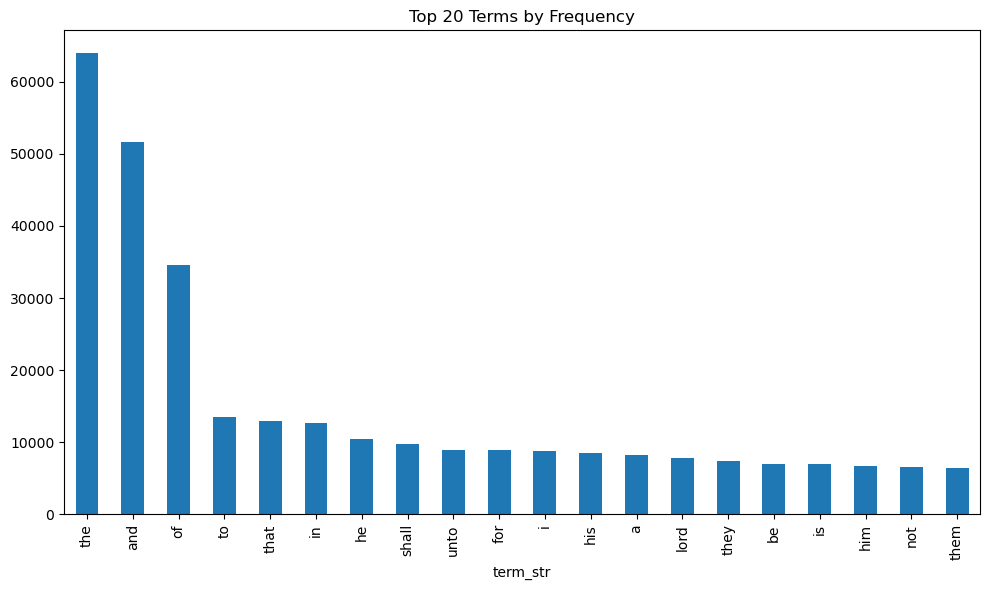

In [22]:
import os

os.makedirs("../graphs", exist_ok=True)

top20 = (
    bow.groupby("term_str")["n"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,6))
top20.plot(kind="bar")
plt.title("Top 20 Terms by Frequency")
plt.tight_layout()
plt.savefig("../graphs/bow_top20.png", dpi=300)
plt.show()